In [1]:
import os
import json
import random
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics

DATASET_ROOT = Path("..") / "smartvision_dataset"
NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "val", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "test", transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 25 | Train: 1750 | Val: 375 | Test: 375


In [3]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze the feature extractor
for param in mobilenet.features.parameters():
    param.requires_grad = False

# Replace classifier head (MobileNetV2's classifier: Dropout + Linear(1280, 1000))
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1280, NUM_CLASSES)
)

mobilenet = mobilenet.to(device)

trainable = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
total = sum(p.numel() for p in mobilenet.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100.0%


Trainable params: 32,025 / 2,255,897


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.classifier.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
print("Optimizer ready.")

Optimizer ready.


In [5]:
EPOCHS = 10
best_val_acc = 0.0
best_model_weights = copy.deepcopy(mobilenet.state_dict())
patience = 5
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    mobilenet.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    mobilenet.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(mobilenet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

mobilenet.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/10 (20.3s) - train_loss: 2.6134, train_acc: 0.2811, val_loss: 1.7836, val_acc: 0.5947
Epoch 2/10 (19.9s) - train_loss: 1.6977, train_acc: 0.5600, val_loss: 1.3591, val_acc: 0.6773
Epoch 3/10 (19.5s) - train_loss: 1.3659, train_acc: 0.6211, val_loss: 1.1575, val_acc: 0.7227
Epoch 4/10 (19.9s) - train_loss: 1.2359, train_acc: 0.6560, val_loss: 1.0864, val_acc: 0.7120
Epoch 5/10 (20.9s) - train_loss: 1.0785, train_acc: 0.6994, val_loss: 1.0015, val_acc: 0.7013
Epoch 6/10 (20.2s) - train_loss: 1.0282, train_acc: 0.7063, val_loss: 0.9461, val_acc: 0.7333
Epoch 7/10 (20.3s) - train_loss: 0.9608, train_acc: 0.7240, val_loss: 0.8878, val_acc: 0.7573
Epoch 8/10 (21.4s) - train_loss: 0.9252, train_acc: 0.7337, val_loss: 0.8919, val_acc: 0.7573
Epoch 9/10 (20.1s) - train_loss: 0.8612, train_acc: 0.7629, val_loss: 0.8429, val_acc: 0.7627
Epoch 10/10 (19.5s) - train_loss: 0.8460, train_acc: 0.7451, val_loss: 0.8222, val_acc: 0.7840

Best validation accuracy: 0.7840


In [6]:
EPOCHS = 10  # additional epochs

for epoch in range(EPOCHS):
    start_time = time.time()

    mobilenet.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    mobilenet.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(mobilenet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

mobilenet.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy so far: {best_val_acc:.4f}")

Epoch 1/10 (20.8s) - train_loss: 0.7966, train_acc: 0.7640, val_loss: 0.8163, val_acc: 0.7787
Epoch 2/10 (19.7s) - train_loss: 0.7692, train_acc: 0.7766, val_loss: 0.8173, val_acc: 0.7787
Epoch 3/10 (20.4s) - train_loss: 0.7598, train_acc: 0.7686, val_loss: 0.7877, val_acc: 0.7707
Epoch 4/10 (20.0s) - train_loss: 0.7288, train_acc: 0.7909, val_loss: 0.7481, val_acc: 0.7760
Epoch 5/10 (21.3s) - train_loss: 0.7200, train_acc: 0.7874, val_loss: 0.7710, val_acc: 0.7813
Early stopping triggered at epoch 5

Best validation accuracy so far: 0.7840


In [7]:
os.makedirs("../models", exist_ok=True)
torch.save(mobilenet.state_dict(), "../models/mobilenetv2_best.pth")
print("Model saved to ../models/mobilenetv2_best.pth")

mobilenet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = metrics.accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(metrics.classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Model saved to ../models/mobilenetv2_best.pth

Test Accuracy: 0.7120

Classification Report:
               precision    recall  f1-score   support

     airplane       1.00      0.93      0.97        15
          bed       0.50      0.93      0.65        15
        bench       0.67      0.27      0.38        15
      bicycle       0.90      0.60      0.72        15
         bird       0.94      1.00      0.97        15
       bottle       0.62      0.53      0.57        15
         bowl       0.53      0.53      0.53        15
          bus       0.79      0.73      0.76        15
         cake       0.86      0.80      0.83        15
          car       0.38      0.40      0.39        15
          cat       1.00      0.73      0.85        15
        chair       0.71      0.67      0.69        15
        couch       0.67      0.67      0.67        15
          cow       0.75      0.80      0.77        15
          cup       0.65      0.73      0.69        15
          dog       0.79  

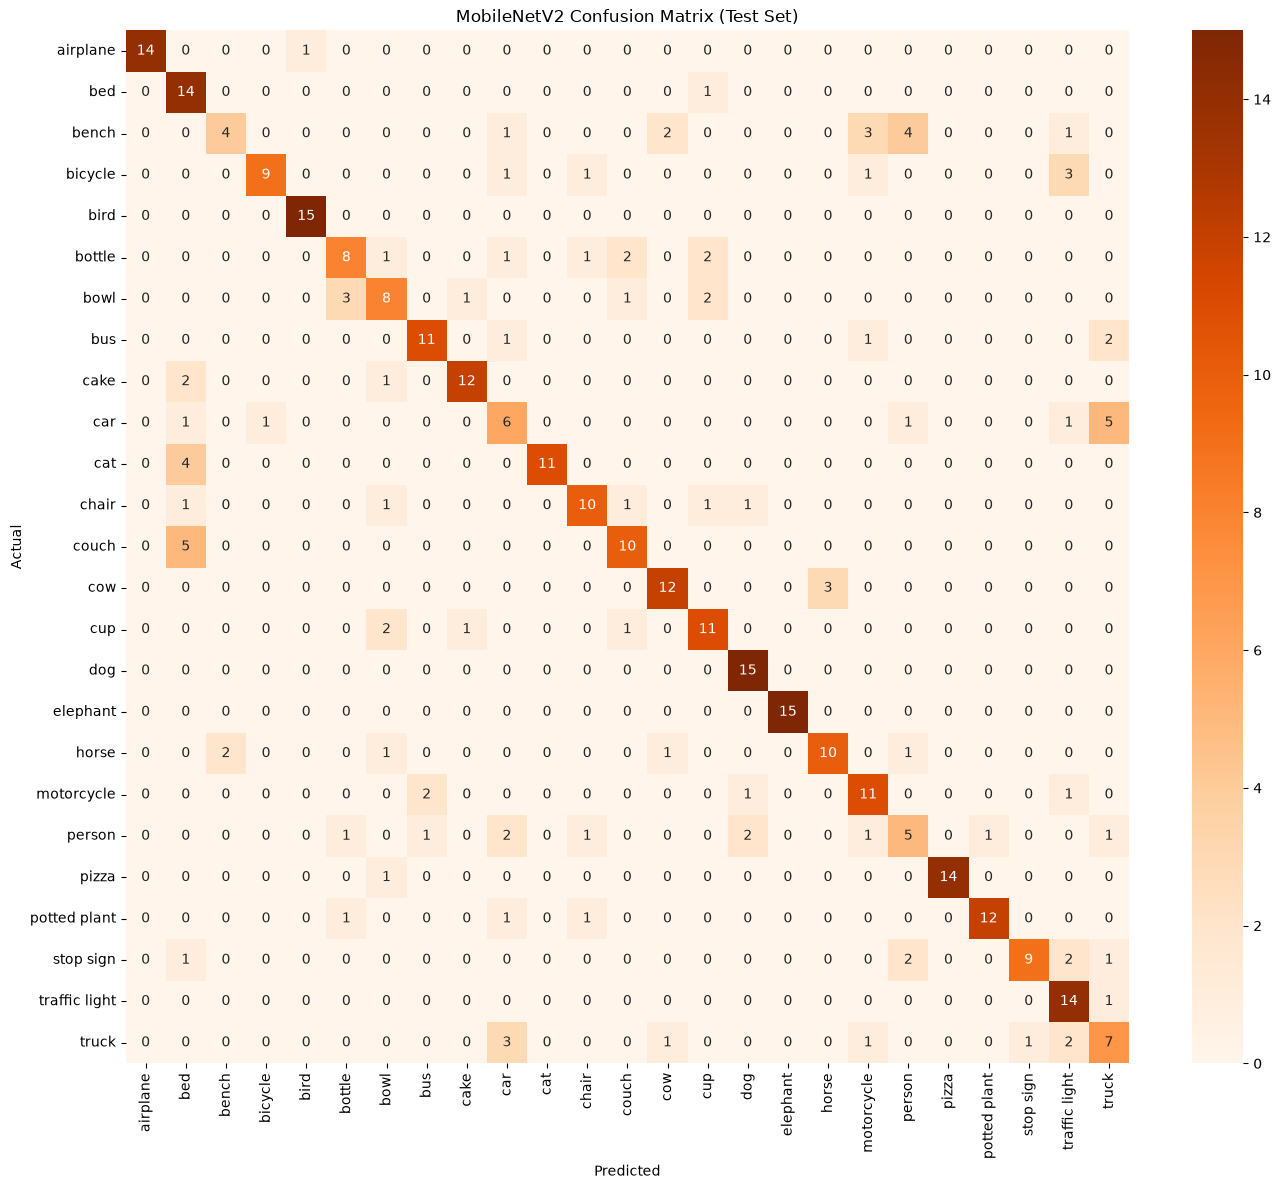

In [8]:
cm = metrics.confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix (Test Set)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/confusion_matrices/mobilenetv2_confusion_matrix.png")
plt.show()